# Tutorial de Sympy y Networkx

Este cuaderno presenta una guía práctica para resolver operaciones básicas del álgebra lineal y visualización de redes. Este tutorial lo dividiremos en dos partes: 

1. **SymPy:** Representación de matrices, extracción de entradas (renglones, columnas y elementos específicos), multiplicación de matrices, cálculo de potencias, producto matriz-vector y obtención de valores y vectores propios.
2. **NetworkX:** Creación y visualización de diagramas de transición.

## 1. Representación y acceso a matrices (SymPy)
Definamos una matriz y de ella vamos a extraer sus componentes.

In [69]:
from sympy import Matrix
from IPython.display import display

# Matriz de 3x3
M = Matrix([[2, 1, 0],[0, 3, 4], [0, 0, -1]])

print("Matriz M:")
display(M)

## Entrada específica (renglón 0, columna 1)
entrada = M[0, 1]
print(f"Entrada (0, 1): {entrada}")

# Obtener un renglón dado (índice 1)
renglon = M.row(1)
print("Segundo renglón:")
display(renglon)

# Obtener una columna dada (índice 0)
columna = M.col(0)
print("Primera columna:")
display(columna)

Matriz M:


Matrix([
[2, 1,  0],
[0, 3,  4],
[0, 0, -1]])

Entrada (0, 1): 1
Segundo renglón:


Matrix([[0, 3, 4]])

Primera columna:


Matrix([
[2],
[0],
[0]])

## 1.1 Multiplicación de matrices y potencias
Las operaciones algebraicas entre matrices en SymPy se realizan de forma directa utilizando los operadores estándar de Python: `*` para el producto y `**` para las potencias.

In [70]:
# Matriz N 3x3
N = Matrix([[2, 0, 0], [0, 3, 4], [0, 4, 9]])

print("Matriz N:")
display(N)

# Multiplicación de matrices (M * N)
producto = M * N
print("Producto de M por N:")
display(producto)

# Elevar al cuadrado la matriz M
potencia = M ** 2
print("Matriz M al cuadrado:")
display(potencia)

Matriz N:


Matrix([
[2, 0, 0],
[0, 3, 4],
[0, 4, 9]])

Producto de M por N:


Matrix([
[4,  3,  4],
[0, 25, 48],
[0, -4, -9]])

Matriz M al cuadrado:


Matrix([
[4, 5, 4],
[0, 9, 8],
[0, 0, 1]])

## 1.2 Producto Matriz-Vector y Valores/Vectores Propios

Multiplicar una matriz por un vector es una operación básica que nos ayuda a ver cómo la matriz modifica a ese vector. En SymPy, un vector columna se crea igual que una matriz, pero usando una sola columna (dimensiones $n \times 1$).

Además, SymPy facilita el cálculo de dos conceptos útiles para las matrices cuadradas:
* **Valores propios (Eigenvalues):** Son números que nos indican qué tanto se estira o se encoge un vector al ser multiplicado por la matriz.
* **Vectores propios (Eigenvectors):** Son vectores especiales que no cambian de dirección cuando la matriz actúa sobre ellos; solo cambian de tamaño.

In [71]:
# Vector columna de 3x1
v = Matrix([[1], [2], [3]])

print("Vector columna v:")
display(v)

# Multiplicar la matriz M por el vector v
producto_vector = M * v
print("Producto de la matriz M por el vector v:")
display(producto_vector)

# Hallar valores propios (eigenvalues)
valores_propios = M.eigenvals()
print("Valores propios de M:")
for valor, multiplicidad in valores_propios.items():
    print(f" -> Valor propio: {valor} (Multiplicidad: {multiplicidad})")

# Hallar vectores propios (eigenvectors)
vectores_propios = M.eigenvects()
print("\nVectores propios de M:")
for valor, multiplicidad, vectores in vectores_propios:
    print(f" -> Vector(es) propio(s) para el valor {valor}:")
    for vec in vectores:
        display(vec) 

Vector columna v:


Matrix([
[1],
[2],
[3]])

Producto de la matriz M por el vector v:


Matrix([
[ 4],
[18],
[-3]])

Valores propios de M:
 -> Valor propio: -1 (Multiplicidad: 1)
 -> Valor propio: 3 (Multiplicidad: 1)
 -> Valor propio: 2 (Multiplicidad: 1)

Vectores propios de M:
 -> Vector(es) propio(s) para el valor -1:


Matrix([
[1/3],
[ -1],
[  1]])

 -> Vector(es) propio(s) para el valor 2:


Matrix([
[1],
[0],
[0]])

 -> Vector(es) propio(s) para el valor 3:


Matrix([
[1],
[1],
[0]])

## 2. Dibujar un Diagrama de Transición (NetworkX)
Un diagrama de transición (o cadena de Markov) se puede representar como un grafo dirigido, donde los nodos son los estados del sistema y las flechas indican la dirección de la transición. 
Utilizaremos `networkx` para construir la estructura de la red y `matplotlib.pyplot` para renderizar la imagen.

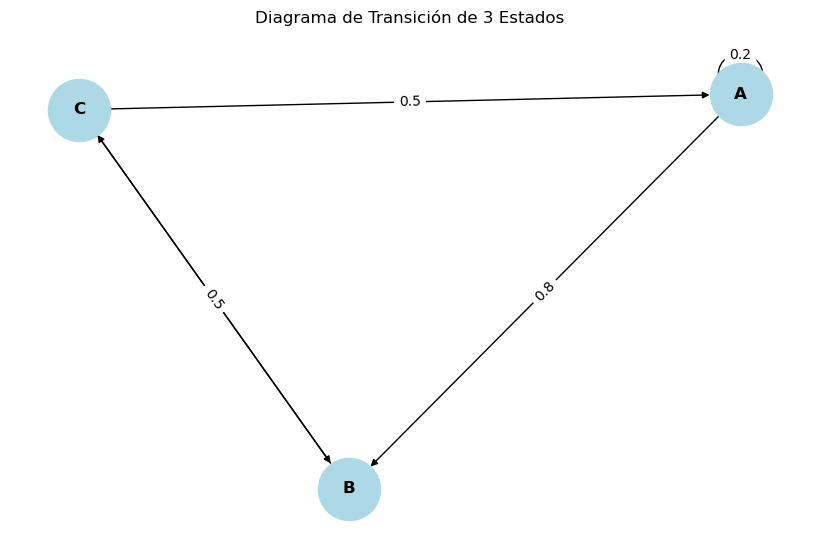

In [74]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Para el grafo dirigido 
G = nx.DiGraph()

# 2. Definir los estados
estados = ['A', 'B', 'C']
G.add_nodes_from(estados)

# 3. Añadimos las transiciones (origen, destino, probabilidad)
transiciones = [('A', 'A', 0.2), ('A', 'B', 0.8), ('B', 'C', 1.0), ('C', 'A', 0.5), ('C', 'B', 0.5)]
G.add_weighted_edges_from(transiciones)

# 4. Para el dibujo del diagrama
plt.figure(figsize=(8, 5))
pos = nx.spring_layout(G) # Separar los nodos visualmente

# Dibujar los nodos, las flechas y las etiquetas de los estados
nx.draw(G, pos, with_labels=True, node_color='lightblue', 
        node_size=2000, font_size=12, font_weight='bold', arrows=True)

# Para colocar las probabilidades sobre las flechas
pesos = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=pesos)

# Resultado
plt.title("Diagrama de Transición de 3 Estados")
plt.axis('off') # Ocultar los ejes numéricos
plt.show()